#### 1: Import Dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Books_Data_Clean.csv")

In [3]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [4]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


###### Analyze Curious:
. There is a negative number in publishing years.

. The minimum rating is 2.97 and the maximum is 4.77, with a 0.24 number here.

. Most of the book have a closer rating to 5 and 4 to 1.

. Roughly 94k booking rating.

In [5]:
df = df[df["Publishing Year"] > 1900] 

In [6]:
df.isna().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          49
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [7]:
df.dropna(subset = "Book Name", inplace = True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

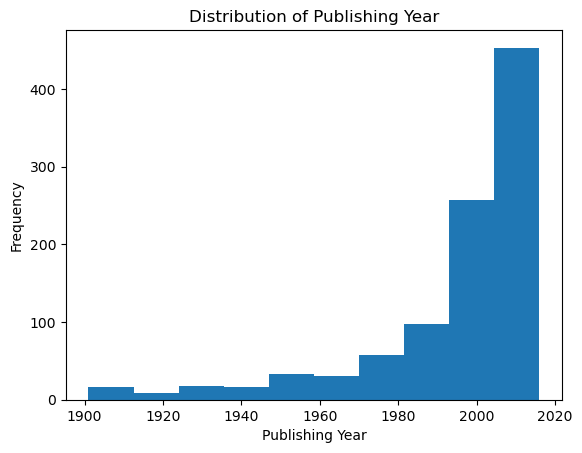

In [10]:
plt.hist(df["Publishing Year"])
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Distribution of Publishing Year")
plt.show()

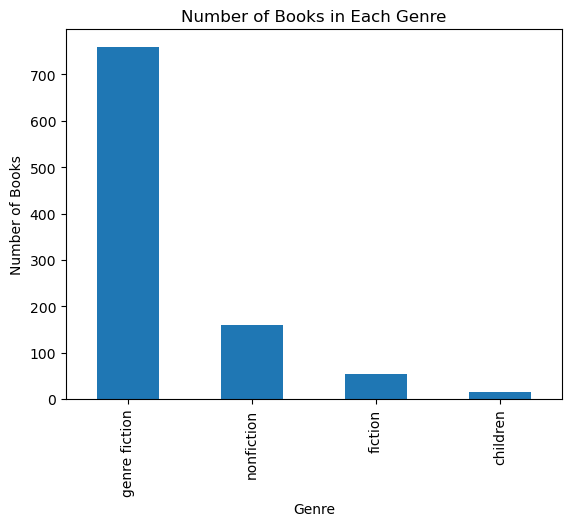

In [11]:
df["genre"].value_counts().plot(kind = "bar")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Number of Books in Each Genre")
plt.show()

In [12]:
df.groupby("Author")["Book_average_rating"].mean()

Author
A.A. Milne, Ernest H. Shepard                      4.36
A.S.A. Harrison                                    3.30
Abbi Glines                                        4.21
Adam Johnson                                       4.06
Adam Mansbach, Ricardo CortÃ©s                     4.26
                                                   ... 
William Styron                                     4.18
Yana Toboso, Tomo Kimura                           4.37
Zadie Smith                                        3.75
Ø£Ø­Ù„Ø§Ù… Ù…Ø³ØªØºØ§Ù†Ù…ÙŠ, Ahlam Mosteghanemi    3.72
Ø£Ø­Ù…Ø¯ Ù…Ø±Ø§Ø¯                                  3.80
Name: Book_average_rating, Length: 669, dtype: float64

In [13]:
df.groupby("Author")["Book_average_rating"].mean().head()

Author
A.A. Milne, Ernest H. Shepard     4.36
A.S.A. Harrison                   3.30
Abbi Glines                       4.21
Adam Johnson                      4.06
Adam Mansbach, Ricardo CortÃ©s    4.26
Name: Book_average_rating, dtype: float64

In [14]:
df.groupby("Author")["Book_average_rating"].mean().tail()

Author
William Styron                                     4.18
Yana Toboso, Tomo Kimura                           4.37
Zadie Smith                                        3.75
Ø£Ø­Ù„Ø§Ù… Ù…Ø³ØªØºØ§Ù†Ù…ÙŠ, Ahlam Mosteghanemi    3.72
Ø£Ø­Ù…Ø¯ Ù…Ø±Ø§Ø¯                                  3.80
Name: Book_average_rating, dtype: float64

In [15]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending = False)

Author
Bill Watterson                  4.650000
Bill Watterson, G.B. Trudeau    4.610000
J.R.R. Tolkien                  4.590000
George R.R. Martin              4.560000
Sarah J. Maas                   4.526000
                                  ...   
Chetan Bhagat                   3.273333
Audrey Niffenegger              3.230000
Herman Koch, Sam Garrett        3.220000
P.D. James                      3.210000
Sue Monk Kidd                   3.100000
Name: Book_average_rating, Length: 669, dtype: float64

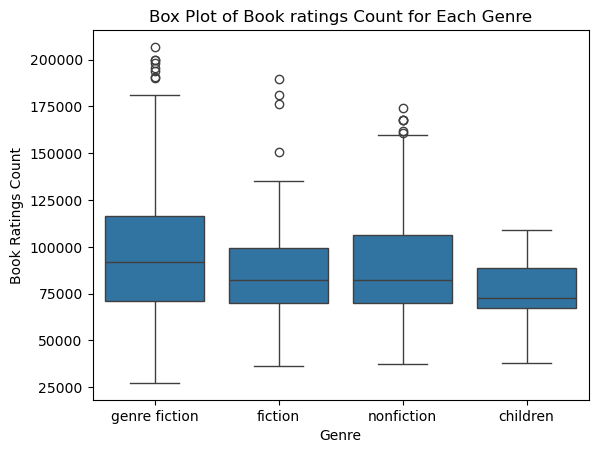

In [16]:
sns.boxplot(x = "genre", y = "Book_ratings_count", data=df)
plt.xlabel("Genre")
plt.ylabel("Book Ratings Count")
plt.title("Box Plot of Book ratings Count for Each Genre")
plt.show()

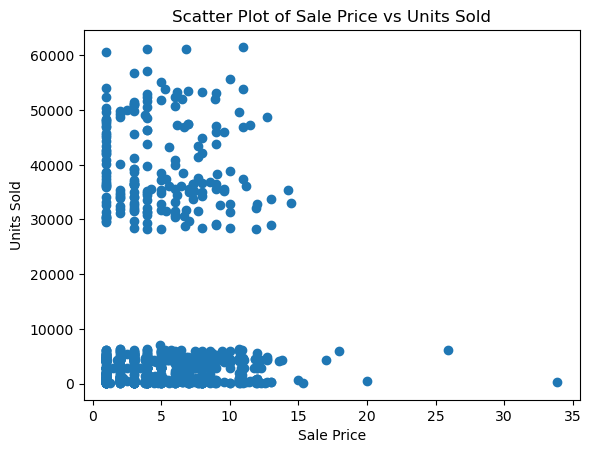

In [17]:
plt.scatter(df["sale price"], df["units sold"])
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.title("Scatter Plot of Sale Price vs Units Sold")
plt.show()

In [18]:
df["language_code"].value_counts()

language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
spa        2
ara        2
nl         1
Name: count, dtype: int64

In [19]:
df["language_code"].value_counts().sort_values(ascending=True)

language_code
nl         1
spa        2
ara        2
fre        4
en-CA      7
en-GB     29
en-US    226
eng      670
Name: count, dtype: int64

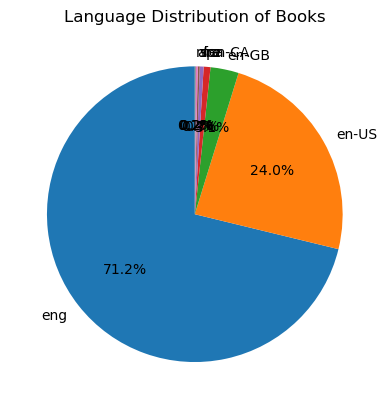

In [20]:
language_counts = df["language_code"].value_counts()

plt.pie(language_counts, labels = language_counts.index, startangle = 90, autopct="%1.1f%%")
plt.title("Language Distribution of Books")
plt.show()

In [21]:
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher ', 'units sold'],
      dtype='object')

In [22]:
df.groupby("Publisher ")["publisher revenue"].sum()

Publisher 
Amazon Digital Services,  Inc.          141767.772
Hachette Book Group                     107410.968
HarperCollins Christian Publishing        2135.670
HarperCollins Publishers                121769.814
HarperCollins Publishing                  2830.806
Macmillan                                31249.830
Penguin Group (USA) LLC                 191581.104
Random House LLC                        174956.244
Simon and Schuster Digital Sales Inc     46858.206
Name: publisher revenue, dtype: float64

In [23]:
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending = False).head()

Author_Rating
Intermediate    101400.272569
Famous           98295.250000
Novice           87318.464286
Excellent        83804.800595
Name: Book_ratings_count, dtype: float64

In [24]:
df.groupby("language_code").size().sort_values(ascending = False)

language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
ara        2
spa        2
nl         1
dtype: int64

In [25]:
df.groupby("Author_Rating")["Book_ratings_count"].mean()

Author_Rating
Excellent        83804.800595
Famous           98295.250000
Intermediate    101400.272569
Novice           87318.464286
Name: Book_ratings_count, dtype: float64

In [26]:
df.groupby("Author_Rating")["Book_ratings_count"].var()

Author_Rating
Excellent       4.419857e+08
Famous          1.227555e+09
Intermediate    1.170331e+09
Novice          9.523157e+08
Name: Book_ratings_count, dtype: float64

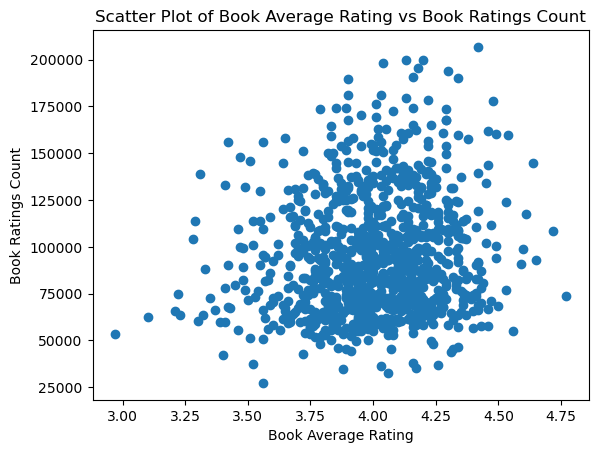

In [27]:
plt.scatter(df["Book_average_rating"],df["Book_ratings_count"])
plt.xlabel("Book Average Rating")
plt.ylabel("Book Ratings Count")
plt.title("Scatter Plot of Book Average Rating vs Book Ratings Count")
plt.show()

In [28]:
total_gross_sales_by_author = df.groupby("Author")["gross sales"].sum()

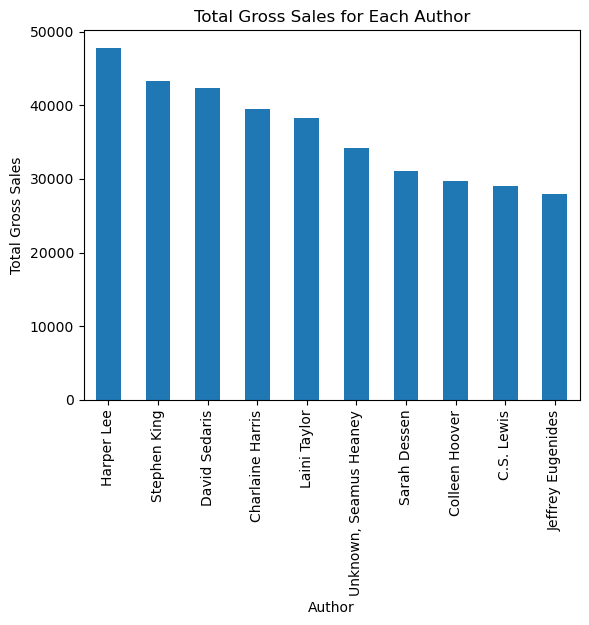

In [29]:
total_gross_sales_by_author.sort_values(ascending = False).head(10).plot(kind = "bar")
plt.xlabel("Author")
plt.ylabel("Total Gross Sales")
plt.title("Total Gross Sales for Each Author")
plt.show()

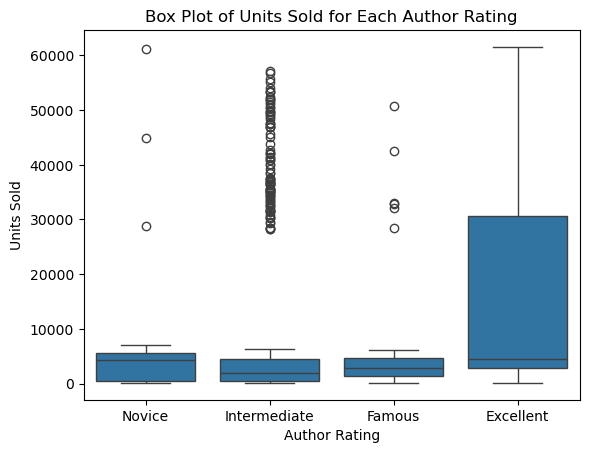

In [31]:
sns.boxplot(x="Author_Rating", y = "units sold", data=df)
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.title("Box Plot of Units Sold for Each Author Rating")
plt.show()

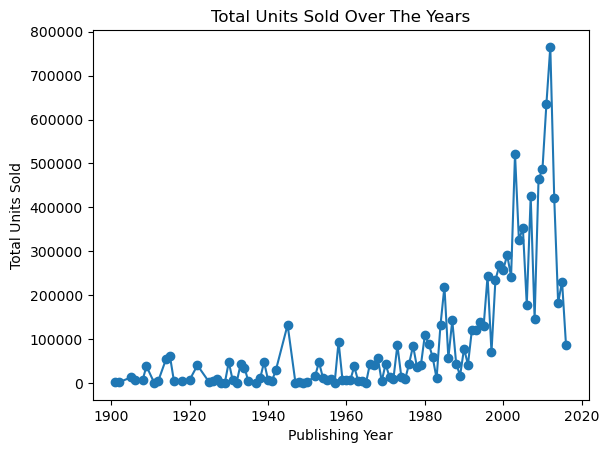

In [34]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind = "line", marker ="o")
plt.xlabel("Publishing Year")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold Over The Years")
plt.show()